In [1]:
import os
import win32com.client as win32
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from sklearn.cluster import MeanShift
import random
import numpy as np

In [2]:
pd.options.display.max_seq_items = 2000

In [3]:
np.random.seed(84)
random.seed(84)

In [4]:
parafins = [ 'methane', 'ethane', 'propane', 
             'butane', 'pentane', 'hexane', 
               'heptane', 'octane', 
             'nonane', 'decane', 'undecane', 'dodecane',
               'tridecane', 'tetradecane', 'pentadecane', 'hexadecane', 'heptadecane',
               'octadecane', 'nonadecane', 'eicosane', 'heneicosane', 'docosane',
               'tricosane', 'tetracosane', 'pentacosane',
               'hexacosane', 'heptacosane',
               'octacosane', 'nonacosane', 'triacontane', 
             'hentriacontane', 'dotriacontane',
               'tritriacontane', 'tetratriacontane', 'pentatriacontane', 'hexatriacontane'
            ]

olefins = [ 'ethylene', 
            'propene',
            '1-butene', '1-pentene', '1-hexene',
            '1-heptene', '1-octene', 
            '1-nonene', '1-decene',
            '1-undecene', '1-dodecene',
            '1-tridecene', '1-tetradecene', '1-pentadecene',
            '1-hexadecene', '1-heptadecene', '1-octadecene',
          ]

others = ['carbon monoxide', 'hydrogen', 'water']

In [5]:
hysys = win32.Dispatch("HYSYS.Application")

os.chdir("Z:\\uem\\Doutorado\\Ensaios\\SAF\\SAF_8_08_08_2025\\SAF_kinetics_paper_code")
path = "hysys_simulation_optimization.hsc"
hy_path = os.path.abspath(path)

hy_case = hysys.Application.ActiveDocument

if hy_case is None:
    hy_case = hysys.SimulationCases.Open(hy_path)
else:
    print(f"Connected to active HYSYS case: {hy_case.Name}")

hy_case.Visible = 1

hy_solver = hy_case.Solver
hy_case.Solver.CanSolve = False

hy_int = hy_solver.Integrator

hy_f = hy_case.Flowsheet

hy_package = hy_f.FluidPackage

hy_ms = hy_f.MaterialStreams
hy_es = hy_f.EnergyStreams

Connected to active HYSYS case: Case


In [6]:
reactor = hy_case.Flowsheet.Operations.Item('PFR-100')

In [7]:
reactor.TotalVolume.GetValue('mL')

7.880000000000001

In [8]:
n_parafins = {}
for i, parafin in enumerate(parafins):
    n = i + 1
    if n not in [4, 5, 6, 7, 8, 31, 32, 33, 34, 35, 36]:
        n_parafins[parafin] = n

n_olefins = {}
for i, olefin in enumerate(olefins):
    n = i + 2
    if n not in [3, 4, 5, 6, 7, 8]:
        n_olefins[olefin] = n

N = list(set(list(n_parafins.values()) + list(n_olefins.values())))

rxn_set = hy_case.BasisManager.ReactionPackageManager.ReactionSets.Item('FTS')

In [9]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

In [10]:
kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

In [11]:
X = kinetic_data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

kinetic_data['cluster'] = clustering.labels_

cluster_set = list(set(kinetic_data.cluster))

val_clusters = random.sample(cluster_set, 2)

In [12]:
loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training = ~loc_validation
idx_training = loc_training.loc[loc_training].index
idx_validation = loc_validation.loc[loc_validation].index
kinetic_data['training'] = loc_training

In [13]:
F1 = hy_ms.Item('F1')
F2 = hy_ms.Item('F2')
P0 = hy_ms.Item('P0')
H2 = hy_ms.Item('H2')
CO = hy_ms.Item('CO')
C1_C3 = hy_ms.Item('C1-C3')
C9_C15 = hy_ms.Item('C9-C15')
C16p = hy_ms.Item('C16p')
unreacted_syngas = hy_ms.Item('unreacted syngas')
water = hy_ms.Item('water')

In [14]:
for i in kinetic_data.index:
    T = kinetic_data.T_R_K[i]
    P = kinetic_data.P_abs_Pa[i]
    F_H2_in =  kinetic_data.F_H2_e_mol_s[i]
    F_CO_in =  kinetic_data.F_CO_e_mol_s[i]
    
    H2.MolarFlow.SetValue(F_H2_in, 'gmole/s')
    CO.MolarFlow.SetValue(F_CO_in, 'gmole/s')
    F1.Pressure.SetValue(P, 'Pa')
    F2.Temperature.SetValue(T, 'K')
    
    # 3. Ligar o solver
    hy_case.Solver.CanSolve = True
    
    # 4. Aguardar a convergência
    while hy_case.Solver.IsSolving:
        pass
    
    hy_case.Solver.CanSolve = False
    
    P0_molar_flow = list(P0.ComponentMolarFlowValue)
    
    F_H2_out = P0_molar_flow[P0.ComponentIndices('Hydrogen')[0]]
    F_CO_out = P0_molar_flow[P0.ComponentIndices('CO')[0]]

    F_H2_in = H2.MolarFlowValue
    F_CO_in = CO.MolarFlowValue
        
    X_CO = (F_CO_in - F_CO_out) / F_CO_in
    X_H2 = (F_H2_in - F_H2_out) / F_H2_in
    print(f'index {i} of {kinetic_data.index.max()}, X_H2: {X_H2}, X_CO: {X_CO}')
    clear_output(wait = True)

    for component in hy_package.Components.Names:
        kinetic_data.loc[i, 
            f'F_{component}_out_hysys'] = P0_molar_flow[
                P0.ComponentIndices(component)[0]] * 1000 # convert from kmol/s to mol/s

kinetic_data.to_pickle('kinetic_data_Hysys.pkl')
kinetic_data.to_excel('kinetic_data_Hysys.ods')

index 272 of 272, X_H2: 0.859950325158289, X_CO: 0.569848462358003


In [15]:
kinetic_data = pd.read_pickle('kinetic_data_Hysys.pkl')

In [16]:
# fig_path = "Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\"
fig_path = ""

In [17]:
cols_Fout_exp = [
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s', 'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
       'F_C17', 'F_C18', 'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24',
       'F_C25', 'F_C26', 'F_C27', 'F_C28', 'F_C29', 'F_C30',
       'F_Olef_C9', 'F_Olef_C10', 'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13',
       'F_Olef_C14', 'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
          ]

In [18]:
cols_Fout_Hysys = [
    'F_Hydrogen_out_hysys', 'F_CO_out_hysys', 'F_H2O_out_hysys',
       'F_Methane_out_hysys', 'F_Ethane_out_hysys', 'F_Propane_out_hysys',
       'F_n-Nonane_out_hysys', 'F_n-Decane_out_hysys', 'F_n-C11_out_hysys',
       'F_n-C12_out_hysys', 'F_n-C13_out_hysys', 'F_n-C14_out_hysys',
       'F_n-C15_out_hysys', 'F_n-C16_out_hysys', 'F_n-C17_out_hysys',
       'F_n-C18_out_hysys', 'F_n-C19_out_hysys', 'F_n-C20_out_hysys',
       'F_n-C21_out_hysys', 'F_n-C22_out_hysys', 'F_n-C23_out_hysys',
       'F_n-C24_out_hysys', 'F_n-C25_out_hysys', 'F_Ethylene_out_hysys',
       'F_1-Nonene_out_hysys', 'F_1-Decene_out_hysys',
       'F_1-Undecene_out_hysys', 'F_1-Dodecene_out_hysys',
       'F_1-Tridecene_out_hysys', 'F_1-Tetradecen_out_hysys',
       'F_1-Pentadecen_out_hysys', 'F_1-Hexadecene_out_hysys',
       'F_1-Octadecene_out_hysys', 'F_1-Heptadecen_out_hysys',
       'F_n-C26_out_hysys', 'F_n-C27_out_hysys', 'F_n-C28_out_hysys',
       'F_n-C29_out_hysys', 'F_n-C30_out_hysys'
]

In [19]:
comp_dict_Hysys = {
    'F_Hydrogen_out_hysys': r'$\mathrm{H_2}$',
    'F_Methane_out_hysys': r'$\mathrm{CH_4}$',
    'F_CO_out_hysys': r'$\mathrm{CO}$',
    'F_Ethylene_out_hysys' : r'$\mathrm{C_2 H_4}$',
    'F_Ethane_out_hysys': r'$\mathrm{C_2 H_6}$',
    'F_Propane_out_hysys': r'$\mathrm{C_3 H_8}$',
    'F_H2O_out_hysys': r'$\mathrm{H_2 O}$',
    'F_n-Nonane_out_hysys': r'$\mathrm{C_9 H_{20}}$',
    'F_n-Decane_out_hysys': r'$\mathrm{C_{10} H_{22}}$',
    'F_n-C11_out_hysys': r'$\mathrm{C_{11} H_{24}}$',
    'F_n-C12_out_hysys': r'$\mathrm{C_{12} H_{26}}$',
    'F_n-C13_out_hysys': r'$\mathrm{C_{13} H_{28}}$',
    'F_n-C14_out_hysys': r'$\mathrm{C_{14} H_{30}}$',
    'F_n-C15_out_hysys': r'$\mathrm{C_{15} H_{32}}$',
    'F_n-C16_out_hysys': r'$\mathrm{C_{16} H_{34}}$',
    'F_n-C17_out_hysys': r'$\mathrm{C_{17} H_{36}}$',
    'F_n-C18_out_hysys': r'$\mathrm{C_{18} H_{38}}$',
    'F_n-C19_out_hysys': r'$\mathrm{C_{19} H_{40}}$',
    'F_n-C20_out_hysys': r'$\mathrm{C_{20} H_{42}}$',
    'F_n-C21_out_hysys': r'$\mathrm{C_{21} H_{44}}$',
    'F_n-C22_out_hysys': r'$\mathrm{C_{22} H_{46}}$',
    'F_n-C23_out_hysys': r'$\mathrm{C_{23} H_{48}}$',
    'F_n-C24_out_hysys': r'$\mathrm{C_{24} H_{50}}$',
    'F_n-C25_out_hysys': r'$\mathrm{C_{25} H_{52}}$',
    'F_n-C26_out_hysys': r'$\mathrm{C_{26} H_{54}}$',
    'F_n-C27_out_hysys': r'$\mathrm{C_{27} H_{56}}$',
    'F_n-C28_out_hysys': r'$\mathrm{C_{28} H_{58}}$',
    'F_n-C29_out_hysys': r'$\mathrm{C_{29} H_{60}}$',
    'F_n-C30_out_hysys': r'$\mathrm{C_{30} H_{62}}$',
    'F_1-Nonene_out_hysys':      r'$\mathrm{C_9 H_{18}}$',
    'F_1-Decene_out_hysys':      r'$\mathrm{C_{10} H_{20}}$',
    'F_1-Undecene_out_hysys':    r'$\mathrm{C_{11} H_{22}}$',
    'F_1-Dodecene_out_hysys':    r'$\mathrm{C_{12} H_{24}}$',
    'F_1-Tridecene_out_hysys':   r'$\mathrm{C_{13} H_{26}}$',
    'F_1-Tetradecen_out_hysys': r'$\mathrm{C_{14} H_{28}}$',
    'F_1-Pentadecen_out_hysys': r'$\mathrm{C_{15} H_{30}}$',
    'F_1-Hexadecene_out_hysys':  r'$\mathrm{C_{16} H_{32}}$',
    'F_1-Heptadecen_out_hysys':  r'$\mathrm{C_{17} H_{34}}$',
    'F_1-Octadecene_out_hysys':  r'$\mathrm{C_{18} H_{36}}$'
}

In [20]:
comp_dict_exp = {
    'F_H2_s_mol_s': r'$\mathrm{H_2}$',
    'F_CH4_s_mol_s': r'$\mathrm{CH_4}$',
    'F_CO_s_mol_s': r'$\mathrm{CO}$',
    'F_C2H4_s_mol_s' : r'$\mathrm{C_2 H_4}$',
    'F_C2H6_s_mol_s': r'$\mathrm{C_2 H_6}$',
    'F_C3H8_s_mol_s': r'$\mathrm{C_3 H_8}$',
    'F_H2O_s_mol_s': r'$\mathrm{H_2 O}$',
    'F_C9': r'$\mathrm{C_9 H_{20}}$',
    'F_C10': r'$\mathrm{C_{10} H_{22}}$',
    'F_C11': r'$\mathrm{C_{11} H_{24}}$',
    'F_C12': r'$\mathrm{C_{12} H_{26}}$',
    'F_C13': r'$\mathrm{C_{13} H_{28}}$',
    'F_C14': r'$\mathrm{C_{14} H_{30}}$',
    'F_C15': r'$\mathrm{C_{15} H_{32}}$',
    'F_C16': r'$\mathrm{C_{16} H_{34}}$',
    'F_C17': r'$\mathrm{C_{17} H_{36}}$',
    'F_C18': r'$\mathrm{C_{18} H_{38}}$',
    'F_C19': r'$\mathrm{C_{19} H_{40}}$',
    'F_C20': r'$\mathrm{C_{20} H_{42}}$',
    'F_C21': r'$\mathrm{C_{21} H_{44}}$',
    'F_C22': r'$\mathrm{C_{22} H_{46}}$',
    'F_C23': r'$\mathrm{C_{23} H_{48}}$',
    'F_C24': r'$\mathrm{C_{24} H_{50}}$',
    'F_C25': r'$\mathrm{C_{25} H_{52}}$',
    'F_C26': r'$\mathrm{C_{26} H_{54}}$',
    'F_C27': r'$\mathrm{C_{27} H_{56}}$',
    'F_C28': r'$\mathrm{C_{28} H_{58}}$',
    'F_C29': r'$\mathrm{C_{29} H_{60}}$',
    'F_C30': r'$\mathrm{C_{30} H_{62}}$',
    'F_Olef_C9': r'$\mathrm{C_9 H_{18}}$',
    'F_Olef_C10': r'$\mathrm{C_{10} H_{20}}$',
    'F_Olef_C11': r'$\mathrm{C_{11} H_{22}}$',
    'F_Olef_C12': r'$\mathrm{C_{12} H_{24}}$',
    'F_Olef_C13': r'$\mathrm{C_{13} H_{26}}$',
    'F_Olef_C14': r'$\mathrm{C_{14} H_{28}}$',
    'F_Olef_C15': r'$\mathrm{C_{15} H_{30}}$',
    'F_Olef_C16': r'$\mathrm{C_{16} H_{32}}$',
    'F_Olef_C17': r'$\mathrm{C_{17} H_{34}}$',
    'F_Olef_C18': r'$\mathrm{C_{18} H_{36}}$'}

In [21]:
leg_labels = {'$\\mathrm{H_2}$': '$\\mathrm{H_2}$',
 '$\\mathrm{CH_4}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{CO}$': '$\\mathrm{CO}$',
 '$\\mathrm{C_2 H_4}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_2 H_6}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_3 H_8}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{H_2 O}$': '$\\mathrm{H_2 O}$',
 '$\\mathrm{C_9 H_{20}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{10} H_{22}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{11} H_{24}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{12} H_{26}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{13} H_{28}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{14} H_{30}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{15} H_{32}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{16} H_{34}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{17} H_{36}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{18} H_{38}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{19} H_{40}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{20} H_{42}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{21} H_{44}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{22} H_{46}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{23} H_{48}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{24} H_{50}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{25} H_{52}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{26} H_{54}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{27} H_{56}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{28} H_{58}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{29} H_{60}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{30} H_{62}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_9 H_{18}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{10} H_{20}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{11} H_{22}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{12} H_{24}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{13} H_{26}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{14} H_{28}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{15} H_{30}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{16} H_{32}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{17} H_{34}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{18} H_{36}}$': '$\\mathrm{C_{n} H_{2n}}$'}

In [22]:
Fout_exp = kinetic_data[cols_Fout_exp]
Fout_exp['training'] = loc_training
Fout_exp['kin_index'] = kinetic_data.index
Fout_exp = Fout_exp.rename(columns=comp_dict_exp) 
Fout_Hysys = kinetic_data[cols_Fout_Hysys]
Fout_Hysys['training'] = loc_training
Fout_Hysys['kin_index'] = kinetic_data.index
Fout_Hysys = Fout_Hysys.rename(columns=comp_dict_Hysys) 

In [23]:
# have to reorder columns
Fout_exp = Fout_exp[Fout_Hysys.columns]

In [24]:
Fout_Hysys = Fout_Hysys.melt(id_vars = ['training', 'kin_index'],
                             var_name = 'component',
                             value_name = 'Fout_Hysys')

In [25]:
Fout_exp = Fout_exp.melt(id_vars = ['training', 'kin_index'],
                         var_name = 'component',
                         value_name = 'Fout_exp')

In [31]:
plotF = pd.concat((Fout_exp, Fout_Hysys.Fout_Hysys), axis = 'columns')

In [32]:
plotF['legend'] = plotF['component'].map(leg_labels)

In [33]:
# plotF = plotF.groupby(['kin_index', 'legend']).sum()

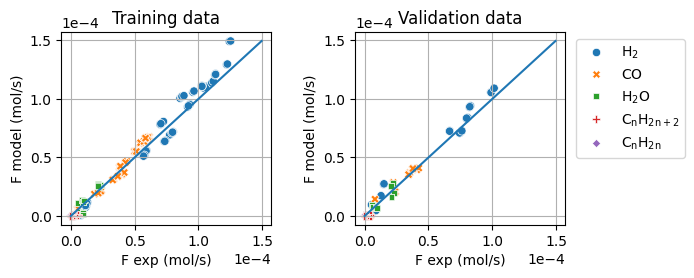

In [43]:
fig, axs = plt.subplots(1,2, figsize=(6.5,2.5))
plt.subplots_adjust(hspace=0.4, wspace = 0.4)
max_xy = max(plotF.Fout_exp.max(), plotF.Fout_Hysys.max())
min_xy = min(plotF.Fout_exp.min(), plotF.Fout_Hysys.min())
scale = 'linear'

sns.scatterplot(
                data=plotF.loc[plotF.training], 
                x='Fout_exp', 
                y='Fout_Hysys', 
                ax = axs[0],
                hue = 'legend',
                style = 'legend',
)

axs[0].plot((0, max_xy), (0, max_xy))
axs[0].set_title('Training data')
axs[0].set_xlabel('F exp (mol/s)')
axs[0].set_ylabel('F model (mol/s)')
axs[0].grid('both')
axs[0].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[0].get_legend().remove()

sns.scatterplot(
                data=plotF.loc[~plotF.training], 
                x='Fout_exp', 
                y='Fout_Hysys', 
                ax = axs[1],
                hue = 'legend',
                style = 'legend',
)


axs[1].plot((0, max_xy), (0, max_xy))
axs[1].set_title('Validation data')
axs[1].set_xlabel('F exp (mol/s)')
axs[1].set_ylabel('F model (mol/s)')
axs[1].grid('both')
axs[1].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[1].legend(bbox_to_anchor=(1.02, 1))

fig_name = 'Fout_parity_Hysys.pdf'
plt.savefig('Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\'+fig_name, 
            bbox_inches = 'tight')

In [35]:
molar_mass_dict = {
 '$\\mathrm{H_2}$':           2,
 '$\\mathrm{CH_4}$':          16,
 '$\\mathrm{CO}$':            12+16,
 '$\\mathrm{C_2 H_4}$':        2*12 + 4,
 '$\\mathrm{C_2 H_6}$':        2*12 + 6,
 '$\\mathrm{C_3 H_8}$':        3*12 + 8,
 '$\\mathrm{H_2 O}$':         18,
 '$\\mathrm{C_9 H_{20}}$':     9*12 + 20,
 '$\\mathrm{C_{10} H_{22}}$': 10*12 + 22,
 '$\\mathrm{C_{11} H_{24}}$': 11*12 + 24,
 '$\\mathrm{C_{12} H_{26}}$': 12*12 + 26,
 '$\\mathrm{C_{13} H_{28}}$': 13*12 + 28,
 '$\\mathrm{C_{14} H_{30}}$': 14*12 + 30,
 '$\\mathrm{C_{15} H_{32}}$': 15*12 + 32,
 '$\\mathrm{C_{16} H_{34}}$': 16*12 + 34,
 '$\\mathrm{C_{17} H_{36}}$': 17*12 + 36,
 '$\\mathrm{C_{18} H_{38}}$': 18*12 + 38,
 '$\\mathrm{C_{19} H_{40}}$': 19*12 + 40,
 '$\\mathrm{C_{20} H_{42}}$': 20*12 + 42,
 '$\\mathrm{C_{21} H_{44}}$': 21*12 + 44,
 '$\\mathrm{C_{22} H_{46}}$': 22*12 + 46,
 '$\\mathrm{C_{23} H_{48}}$': 23*12 + 48,
 '$\\mathrm{C_{24} H_{50}}$': 24*12 + 50,
 '$\\mathrm{C_{25} H_{52}}$': 25*12 + 52,
 '$\\mathrm{C_{26} H_{54}}$': 26*12 + 54,
 '$\\mathrm{C_{27} H_{56}}$': 27*12 + 56,
 '$\\mathrm{C_{28} H_{58}}$': 28*12 + 58,
 '$\\mathrm{C_{29} H_{60}}$': 29*12 + 60,
 '$\\mathrm{C_{30} H_{62}}$': 30*12 + 62,
 '$\\mathrm{C_9 H_{18}}$':     9*12 + 18,
 '$\\mathrm{C_{10} H_{20}}$': 10*12 + 20,
 '$\\mathrm{C_{11} H_{22}}$': 11*12 + 22,
 '$\\mathrm{C_{12} H_{24}}$': 12*12 + 24,
 '$\\mathrm{C_{13} H_{26}}$': 13*12 + 26,
 '$\\mathrm{C_{14} H_{28}}$': 14*12 + 28,
 '$\\mathrm{C_{15} H_{30}}$': 15*12 + 30,
 '$\\mathrm{C_{16} H_{32}}$': 16*12 + 32,
 '$\\mathrm{C_{17} H_{34}}$': 17*12 + 34,
 '$\\mathrm{C_{18} H_{36}}$': 18*12 + 36}

In [36]:
plotF['MM (g/mol)'] = plotF.component.map(molar_mass_dict)

In [37]:
plotF.columns

Index(['training', 'kin_index', 'component', 'Fout_exp', 'Fout_Hysys',
       'legend', 'MM (g/mol)'],
      dtype='str')

In [38]:
plotF[r'$\dot{m}_{\mathrm{out,exp}}$ (g/d)'] = (
    86400 * plotF['MM (g/mol)'] * plotF['Fout_exp']
)
plotF[r'$\dot{m}_{\mathrm{out,Hysys}}$ (g/d)'] = (
    86400 * plotF['MM (g/mol)'] * plotF['Fout_Hysys']
)

In [39]:
plot_m = plotF.groupby(['kin_index', 'legend']).sum()

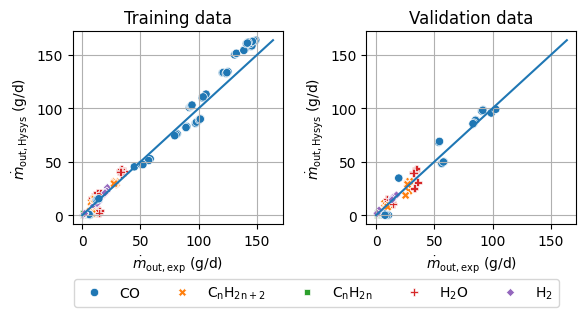

In [46]:
fig, axs = plt.subplots(1,2, figsize=(6.5,2.5))
plt.subplots_adjust(hspace=0.4, wspace = 0.4)
max_xy = max(plotF[r'$\dot{m}_{\mathrm{out,exp}}$ (g/d)'].max(), 
             plotF[r'$\dot{m}_{\mathrm{out,Hysys}}$ (g/d)'].max())
scale = 'linear'

sns.scatterplot(
                data=plot_m.loc[idx_training], 
                x=r'$\dot{m}_{\mathrm{out,exp}}$ (g/d)', 
                y=r'$\dot{m}_{\mathrm{out,Hysys}}$ (g/d)', 
                ax = axs[0],
                hue = 'legend',
                style = 'legend',
)

axs[0].plot((0, max_xy), (0, max_xy))
axs[0].set_title('Training data')
axs[0].grid('both')
axs[0].set_xscale(scale)
axs[0].set_yscale(scale)
# axs[0].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[0].get_legend().remove()

sns.scatterplot(
                data=plot_m.loc[idx_validation], 
                x=r'$\dot{m}_{\mathrm{out,exp}}$ (g/d)', 
                y=r'$\dot{m}_{\mathrm{out,Hysys}}$ (g/d)', 
                ax = axs[1],
                hue = 'legend',
                style = 'legend',
)


axs[1].plot((0, max_xy), (0, max_xy))
axs[1].set_title('Validation data')
axs[1].grid('both')
axs[1].set_xscale(scale)
axs[1].set_yscale(scale)
# axs[1].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[1].get_legend().remove()

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.25), # Adjust 0.92 to move it up or down
           ncol=5, 
           frameon=True)

fig_name = 'm_out_parity_Hysys.pdf'
plt.savefig('Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\'+fig_name, 
            bbox_inches = 'tight')